<a href="https://colab.research.google.com/github/OmkarMishra2176/1st-_repo/blob/main/housing_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv("Housing.csv");


In [49]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [51]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [52]:
df.isnull().sum() #Checking For Null values

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [53]:
df.duplicated().sum() #Checking For Duplicates

np.int64(0)

In [54]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [55]:
num_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'price']
cat_features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea','furnishingstatus']

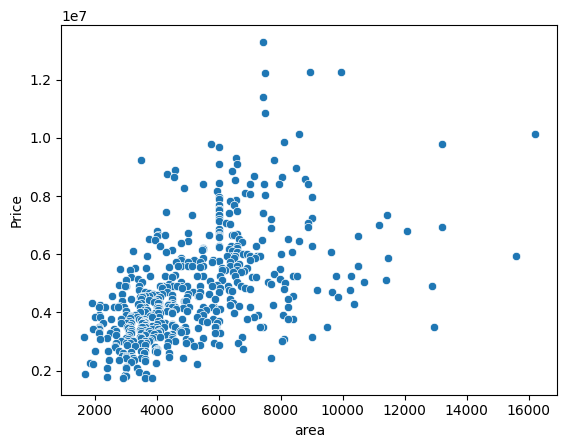

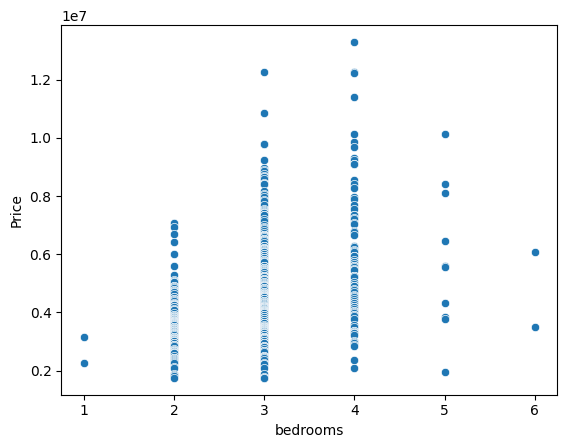

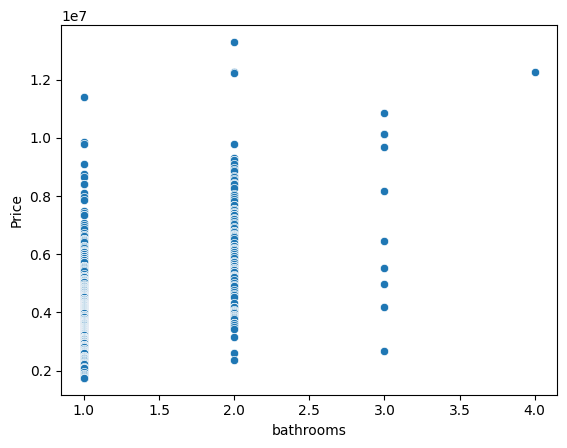

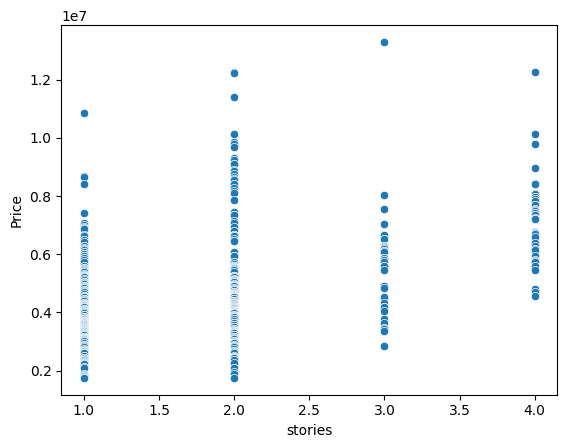

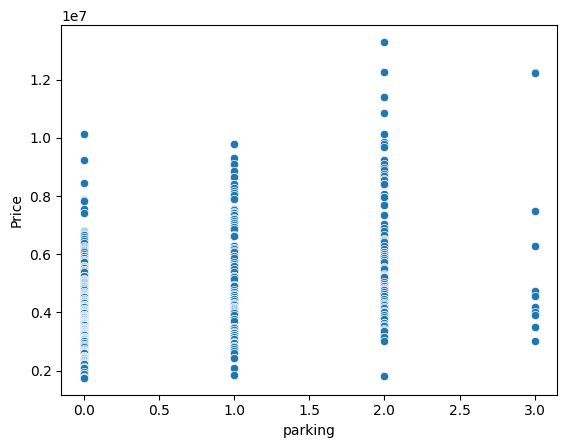

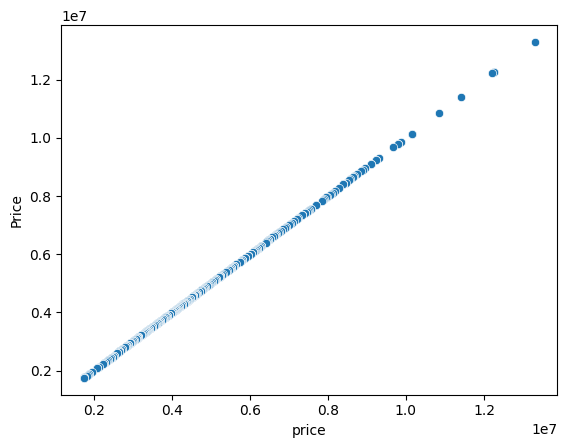

In [56]:
for i in num_features:
  sns.scatterplot(x=df[i], y=df['price'])
  plt.xlabel(i)
  plt.ylabel('Price')
  plt.show()

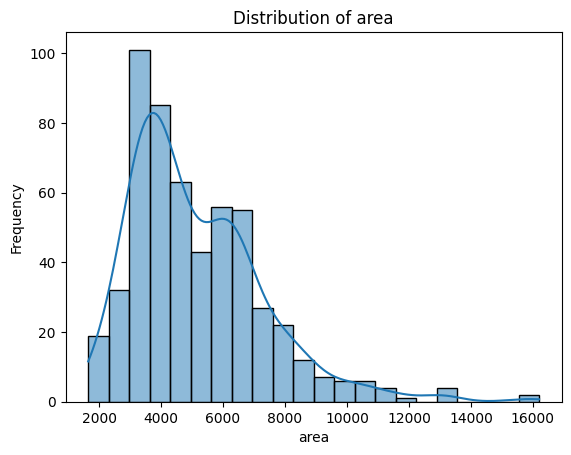

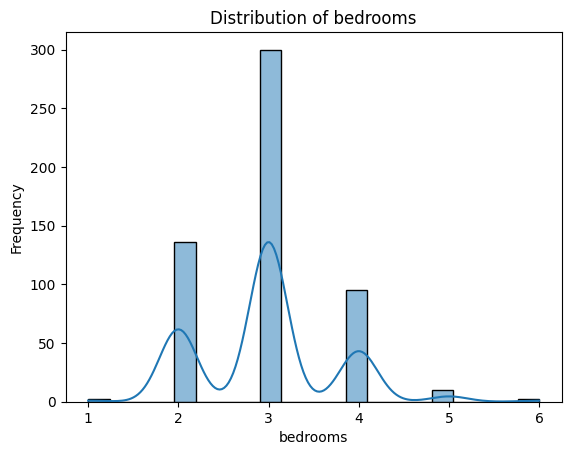

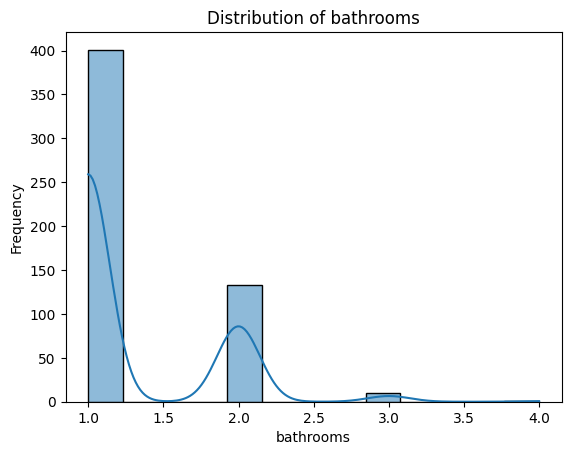

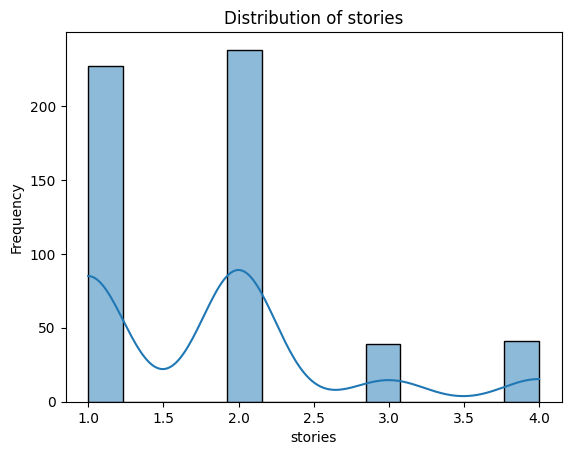

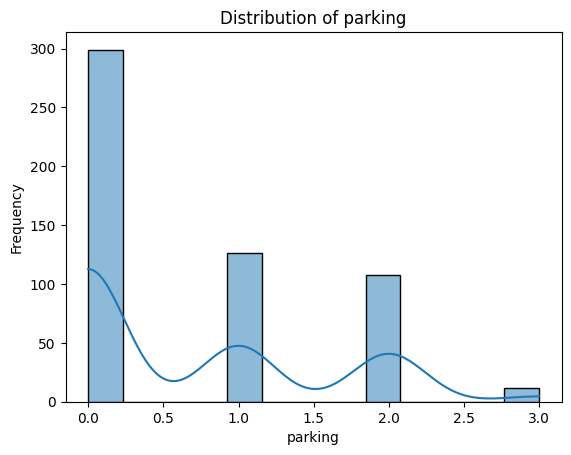

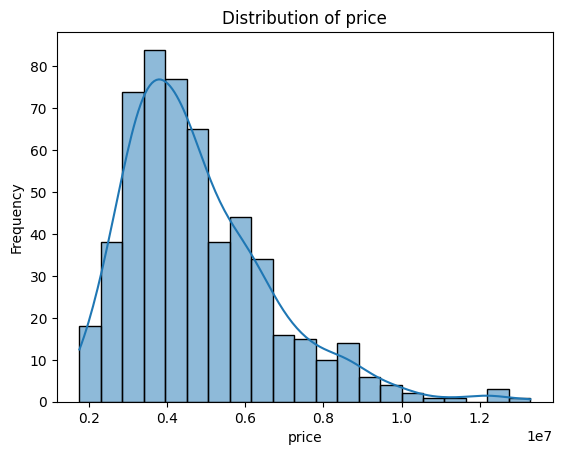

In [57]:
for i in num_features:
  sns.histplot(x=df[i] , kde=True)
  plt.title(f'Distribution of {i}')
  plt.xlabel(i)
  plt.ylabel('Frequency')
  plt.show()

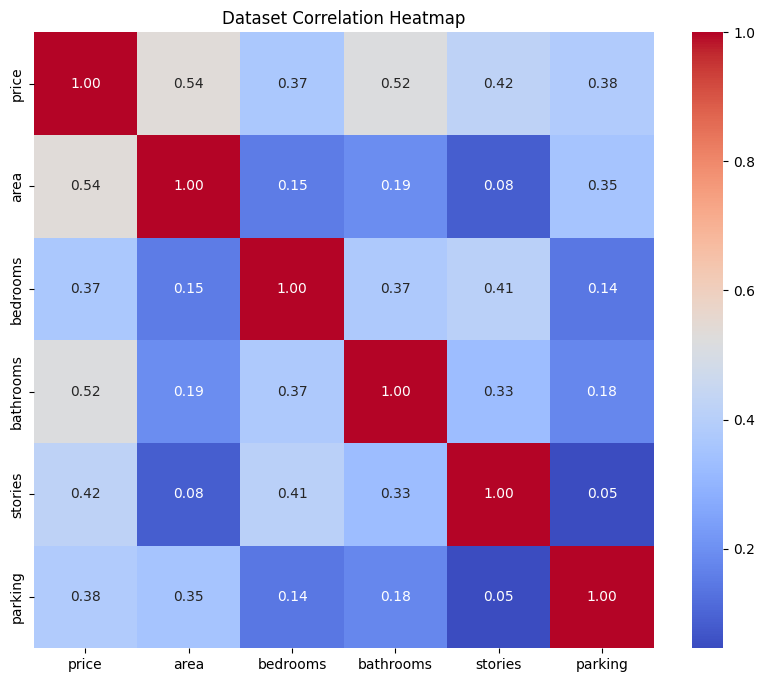

In [58]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Dataset Correlation Heatmap')
plt.show()

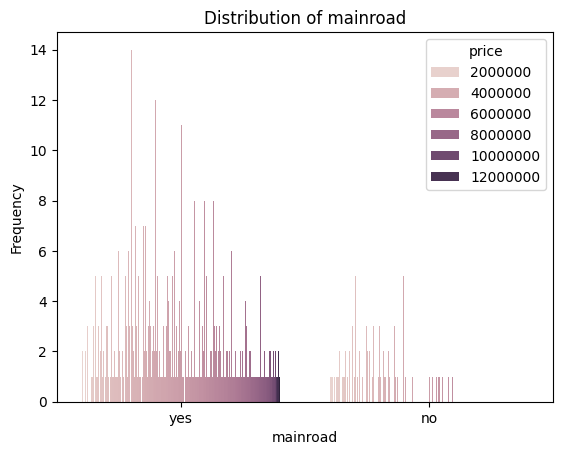

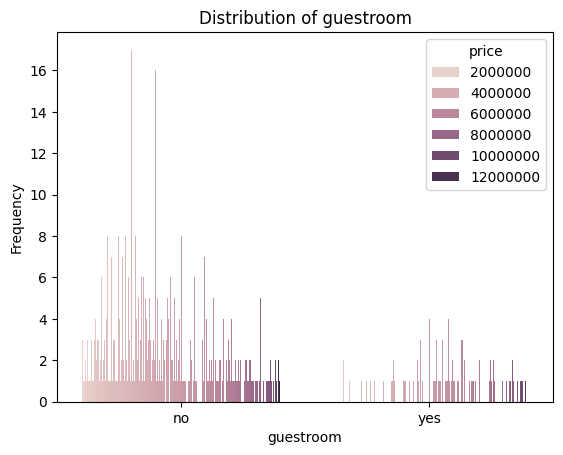

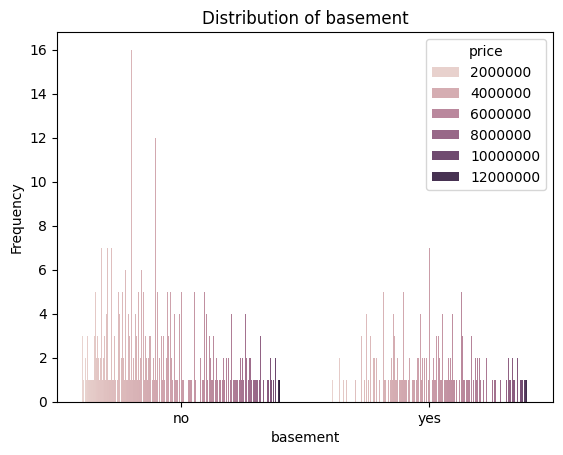

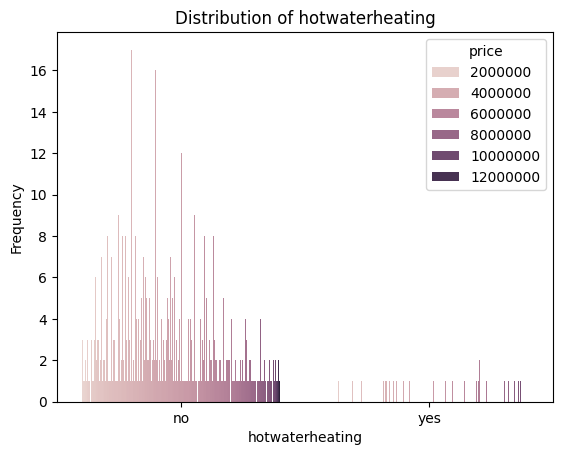

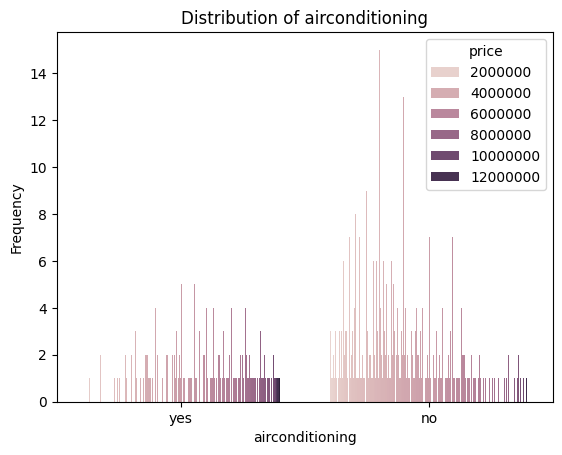

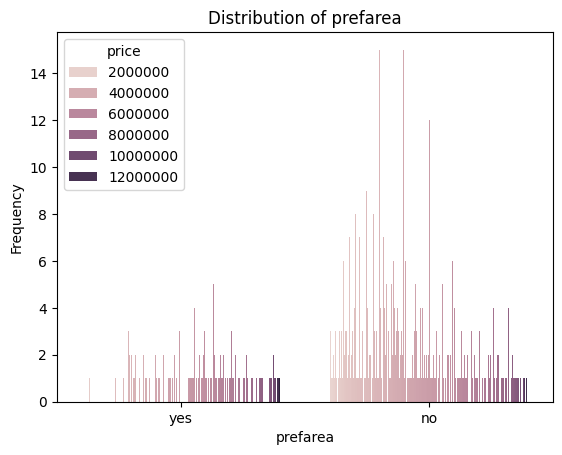

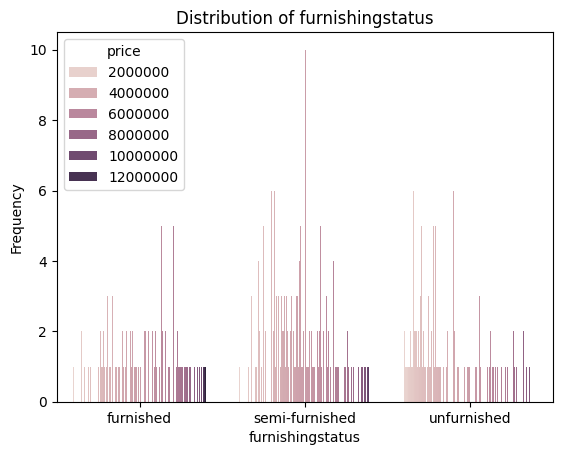

In [59]:
for i in cat_features:
  sns.countplot(x=df[i],hue = df['price'])
  plt.title(f'Distribution of {i}')
  plt.xlabel(i)
  plt.ylabel('Frequency')
  plt.show()

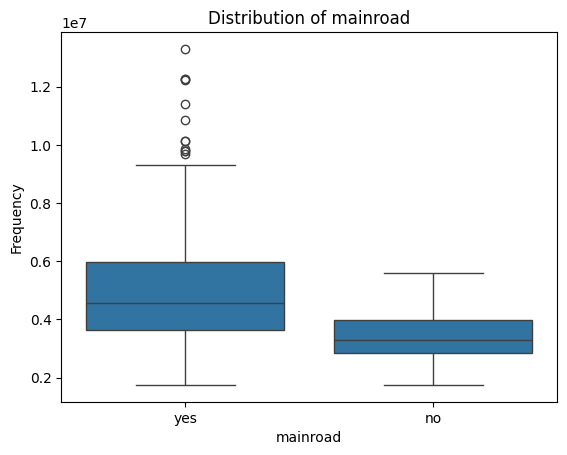

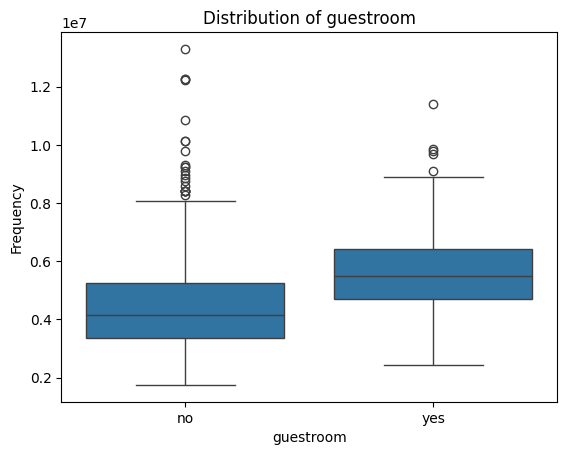

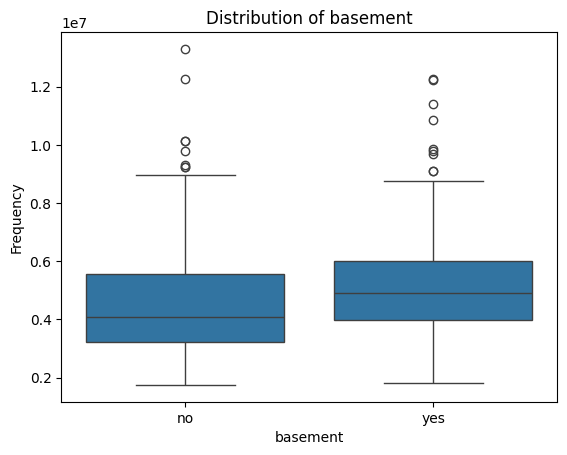

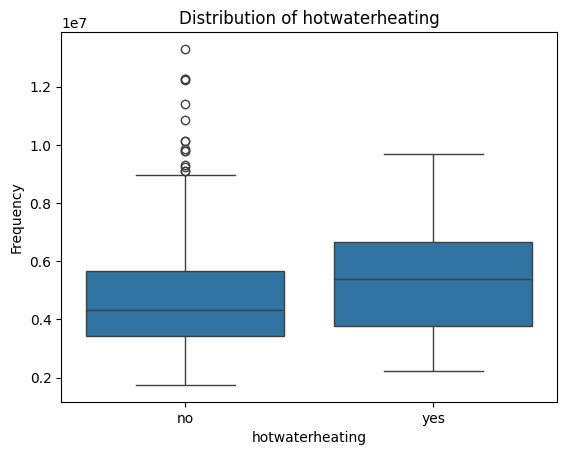

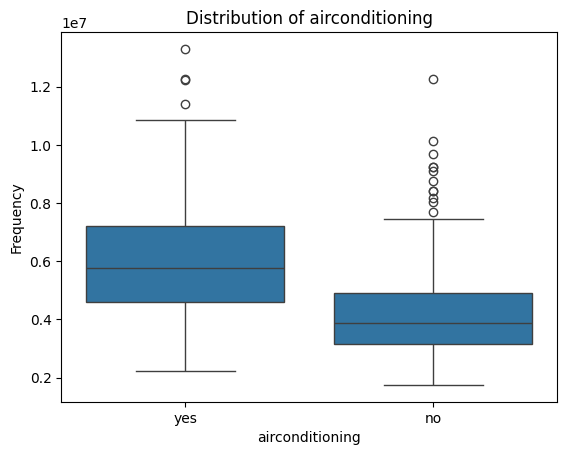

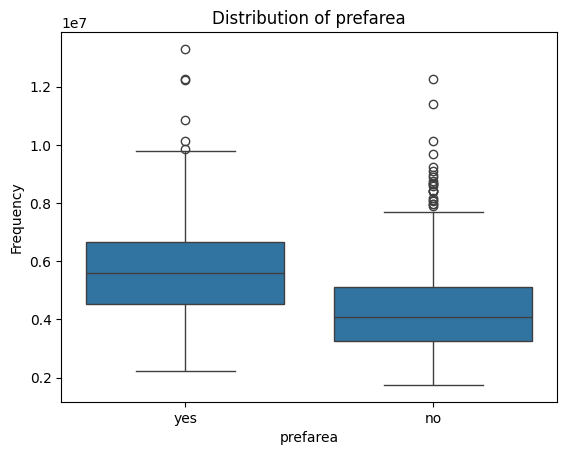

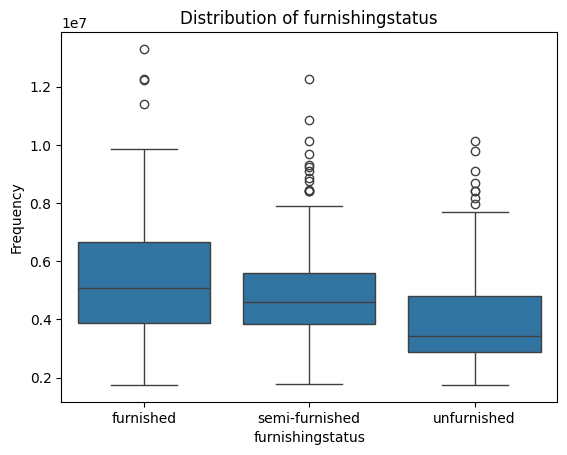

In [60]:
for i in cat_features:
  sns.boxplot(x=df[i], y=df['price'])
  plt.title(f'Distribution of {i}')
  plt.xlabel(i)
  plt.ylabel('Frequency')
  plt.show()

In [61]:
drop_col = ['stories','price']
df_cleaned = df.drop(columns=drop_col)

In [62]:
df_cleaned.columns

Index(['area', 'bedrooms', 'bathrooms', 'mainroad', 'guestroom', 'basement',
       'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')

In [63]:
df_encoded = pd.get_dummies(df_cleaned, columns=cat_features, drop_first=True)

display(df_encoded.head())

print(f"Shape of DataFrame after one-hot encoding: {df_encoded.shape}")

,area,bedrooms,bathrooms,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,2,True,False,False,False,True,True,False,False
1,8960,4,4,3,True,False,False,False,True,False,False,False
2,9960,3,2,2,True,False,True,False,False,True,True,False
3,7500,4,2,3,True,False,True,False,True,True,False,False
4,7420,4,1,2,True,True,True,False,True,False,False,False


Shape of DataFrame after one-hot encoding: (545, 12)


In [64]:
boolean_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[boolean_cols] = df_encoded[boolean_cols].astype(int)

print("DataFrame after converting boolean columns to integers:")
display(df_encoded.head())

DataFrame after converting boolean columns to integers:


,area,bedrooms,bathrooms,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,2,1,0,0,0,1,1,0,0
1,8960,4,4,3,1,0,0,0,1,0,0,0
2,9960,3,2,2,1,0,1,0,0,1,1,0
3,7500,4,2,3,1,0,1,0,1,1,0,0
4,7420,4,1,2,1,1,1,0,1,0,0,0


In [65]:
from sklearn.preprocessing import StandardScaler
numerical_cols_to_scale = ['area', 'bedrooms', 'bathrooms', 'parking']
binary_cols = [col for col in df_encoded.columns if col not in numerical_cols_to_scale]

scaler = StandardScaler()

df_scaled_numerical = pd.DataFrame(scaler.fit_transform(df_encoded[numerical_cols_to_scale]),
                                   columns=numerical_cols_to_scale,
                                   index=df_encoded.index)
df_scaled = pd.concat([df_scaled_numerical, df_encoded[binary_cols]], axis=1)

print("DataFrame after selective Standard Scaling (numerical features only scaled):")
display(df_scaled.head())

DataFrame after selective Standard Scaling (numerical features only scaled):


,area,bedrooms,bathrooms,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.046726,1.403419,1.421812,1.517692,1,0,0,0,1,1,0,0
1,1.757010,1.403419,5.405809,2.679409,1,0,0,0,1,0,0,0
2,2.218232,0.047278,1.421812,1.517692,1,0,1,0,0,1,1,0
3,1.083624,1.403419,1.421812,2.679409,1,0,1,0,1,1,0,0
4,1.046726,1.403419,-0.570187,1.517692,1,1,1,0,1,0,0,0


In [66]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
X = df_scaled
y = df['price']

In [67]:
X

,area,bedrooms,bathrooms,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.046726,1.403419,1.421812,1.517692,1,0,0,0,1,1,0,0
1,1.757010,1.403419,5.405809,2.679409,1,0,0,0,1,0,0,0
2,2.218232,0.047278,1.421812,1.517692,1,0,1,0,0,1,1,0
3,1.083624,1.403419,1.421812,2.679409,1,0,1,0,1,1,0,0
4,1.046726,1.403419,-0.570187,1.517692,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
540,-0.991879,-1.308863,-0.570187,1.517692,1,0,1,0,0,0,0,1
541,-1.268613,0.047278,-0.570187,-0.805741,0,0,0,0,0,0,1,0
542,-0.705921,-1.308863,-0.570187,-0.805741,1,0,0,0,0,0,0,1
543,-1.033389,0.047278,-0.570187,-0.805741,0,0,0,0,0,0,0,0


In [68]:
y

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000
...,...
540,1820000
541,1767150
542,1750000
543,1750000


In [69]:
model = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [70]:
model.fit(X_train, y_train)

LinearRegression()

In [71]:
y_pred = model.predict(X_test)

In [72]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Test RMSE: {rmse_test:.2f}')

r2_test = r2_score(y_test, y_pred)
print(f'Test R2 Score (Model Confidence): {r2_test:.2f}')

y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
print(f'Train R2 Score (Model Confidence): {r2_train:.2f}')

Test RMSE: 1395619.44
Test R2 Score (Model Confidence): 0.61
Train R2 Score (Model Confidence): 0.66


In [73]:
model.score(X_test,y_test)

0.6146549498531506

In [74]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

y_pred_poly = model_poly.predict(X_test_poly)

rmse_test_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_test_poly = r2_score(y_test, y_pred_poly)

y_train_pred_poly = model_poly.predict(X_train_poly)
r2_train_poly = r2_score(y_train, y_train_pred_poly)

print(f'Polynomial Model Test RMSE: {rmse_test_poly:.2f}')
print(f'Polynomial Model Test R2 Score: {r2_test_poly:.2f}')
print(f'Polynomial Model Train R2 Score: {r2_train_poly:.2f}')


Polynomial Model Test RMSE: 1392920.47
Polynomial Model Test R2 Score: 0.62
Polynomial Model Train R2 Score: 0.77


In [75]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_test_ridge = r2_score(y_test, y_pred_ridge)

y_train_pred_ridge = ridge_model.predict(X_train)
r2_train_ridge = r2_score(y_train, y_train_pred_ridge)

print(f'Ridge Regression Test RMSE: {rmse_test_ridge:.2f}')
print(f'Ridge Regression Test R2 Score: {r2_test_ridge:.2f}')
print(f'Ridge Regression Train R2 Score: {r2_train_ridge:.2f}')


Ridge Regression Test RMSE: 1397254.61
Ridge Regression Test R2 Score: 0.61
Ridge Regression Train R2 Score: 0.66


In [76]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_test_rf = r2_score(y_test, y_pred_rf)

y_train_pred_rf = rf_model.predict(X_train)
r2_train_rf = r2_score(y_train, y_train_pred_rf)

print(f'Random Forest Regressor Test RMSE: {rmse_test_rf:.2f}')
print(f'Random Forest Regressor Test R2 Score: {r2_test_rf:.2f}')
print(f'Random Forest Regressor Train R2 Score: {r2_train_rf:.2f}')


Random Forest Regressor Test RMSE: 1397544.22
Random Forest Regressor Test R2 Score: 0.61
Random Forest Regressor Train R2 Score: 0.94


In [77]:
rf_model.score(X_test,y_test)

0.6135913126665966

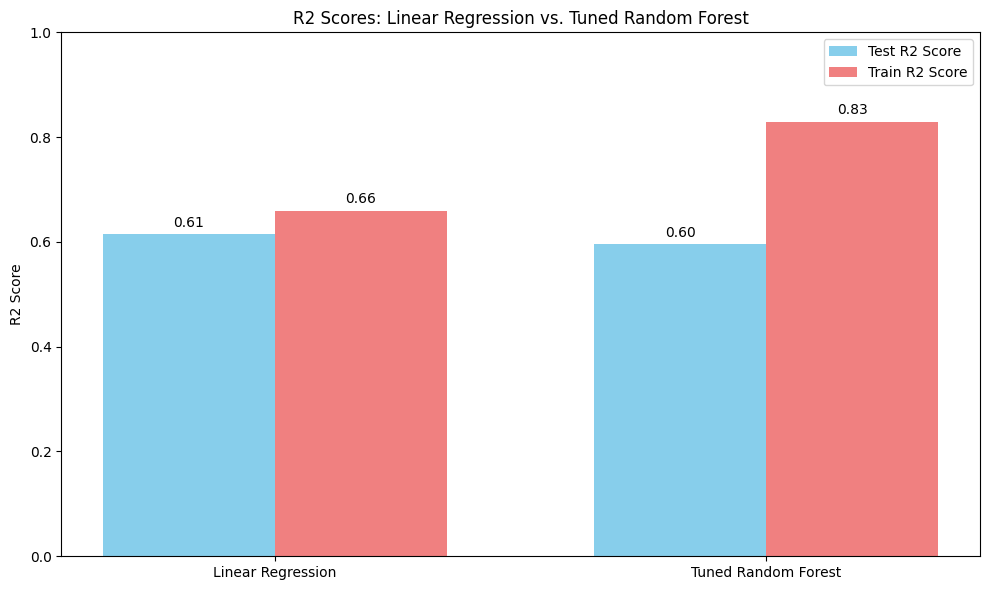

In [79]:
model_names = ['Linear Regression', 'Tuned Random Forest']

test_r2_scores = [r2_test, r2_test_tuned_rf]
train_r2_scores = [r2_train, r2_train_tuned_rf]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, test_r2_scores, width, label='Test R2 Score', color='skyblue')
rects2 = ax.bar(x + width/2, train_r2_scores, width, label='Train R2 Score', color='lightcoral')

ax.set_ylabel('R2 Score')
ax.set_title('R2 Scores: Linear Regression vs. Tuned Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 1)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()


## Insights & Summary

Our analysis reveals that **area** is the most significant numerical feature influencing house prices, exhibiting the strongest positive correlation. Among categorical features, **air conditioning** and **prefarea** (proximity to preferred areas) also show a notable positive impact on price, as do certain furnishing statuses. Our initial Linear Regression model achieved an R2 score of approximately 0.61 on the test set, meaning about **61% of the variation in house prices can be explained by our model's features**. This indicates a moderately accurate model, leaving roughly 39% of price variation unexplained. What was surprising was that more complex models like the Random Forest Regressor, even after hyperparameter tuning, did not significantly outperform the simpler Linear Regression model on unseen data, suggesting that the current features might have largely linear relationships or that further, more advanced feature engineering is required. A key recommendation for a real estate business based on these findings would be to **highlight the square footage (area) and presence of amenities like air conditioning, along with proximity to preferred areas, as primary selling points** when marketing properties, as these factors most strongly drive price.